In [1]:
import os
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
FIGURE_DIR = "../output/figures/clustering"
os.makedirs(FIGURE_DIR, exist_ok=True)

In [3]:
def save_figure(filename_stem, directory=FIGURE_DIR):
    """Save the current matplotlib figure as pdf, png and svg."""
    for ext in ["pdf", "png", "svg"]:
        plt.savefig(f"{directory}/{filename_stem}.{ext}", dpi=300, bbox_inches="tight")

df = pd.read_pickle("../output/data/merged_analysis_data_standardized.pkl")

In [9]:
cluster_label_map = {
    0: 'Mixed Shift',
    1: 'Day Shift',
    2: 'Weekend Shift',
}

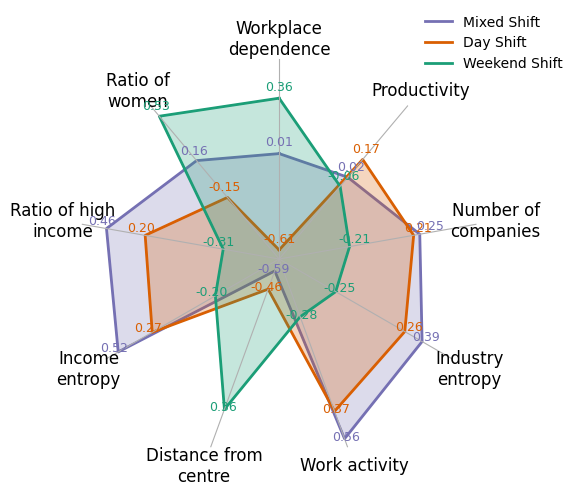

In [21]:
# Order: Workplace dependence (top) -> company/work variables -> distance -> socioeconomic
categories = [
    'work_abs_diff',  'productivity', 'n_companies',
    'entropy', 'loc_work_gaussian_opening','distance_to_deak', 'income_entr_open', 'arpu_high_ratio_open', 'sex_fem_ratio_open'
]
category_label = [
    'Workplace dependence',  'Productivity', 'Number of companies',
    'Industry entropy', 'Work activity', 'Distance from centre', 'Income entropy',
     'Ratio of high income', 'Ratio of women'
]
category_label = ['\n'.join(textwrap.wrap(label, width=13)) for label in category_label]

angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += [angles[0]]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
#colors = [ '#7570b3',  '#d95f02','#1b9e77']
color_map = {0: '#7570b3', 1: '#d95f02', 2: '#1b9e77'}
clusters = [0, 1, 2]

# Orient so the first category (Workplace dependence) sits at the top, going clockwise
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Compute every cluster's values first - needed so the text-placement pass below can see
# all three clusters' values at a given angle at once, to detect and avoid overlap
all_values = []
for cluster in clusters:
    subset = df[df[f'work_cluster_{cluster}'] == 1]
    values = [subset[cat].mean() for cat in categories]
    values += [values[0]]
    all_values.append(values)

#  Draw lines/fills
for i, cluster in enumerate(clusters):
    ax.plot(angles, all_values[i], label=cluster_label_map[cluster],
             color=color_map[cluster], linewidth=2, zorder=1)
    ax.fill(angles, all_values[i], color=color_map[cluster], alpha=0.25)

# Place value annotations, staggering any that would overlap at the same angle.
# Fixed offsets (as before) can put two clusters' labels right on top of each other if
# their values are close - instead, sort the values at each angle and enforce a minimum
# radial gap between consecutive labels.
MIN_LABEL_GAP = 0.08
TEXT_OFFSET = 0.03

for cat_idx, angle in enumerate(angles[:-1]):
    entries = sorted(
        [(all_values[i][cat_idx], i) for i in range(len(clusters))],
        key=lambda entry: entry[0]
    )
    last_pos = None
    for value, cluster_i in entries:
        pos = value if last_pos is None else max(value, last_pos + MIN_LABEL_GAP)
        last_pos = pos
        cluster_num = clusters[cluster_i]
        ax.text(angle, pos + TEXT_OFFSET, f'{value:.2f}',
                ha='center', va='bottom', fontsize=9, color=color_map[cluster_num])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(category_label, fontsize=12)
ax.yaxis.set_visible(False)

ax.legend(loc='upper right', bbox_to_anchor=(1.24, 1.14), frameon=False)
ax.yaxis.grid(True, which='major', linestyle='dashed', linewidth=0.2, color='white', zorder=2)
ax.spines['polar'].set_visible(False)

plt.tight_layout()
save_figure("radar_cluster")
plt.show()